Combine DDS

In [2]:
!pip install UpSetPlot

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for UpSetPlot: filename=UpSetPlot-0.9.0-py3-none-any.whl size=24820 sha256=79cb32d98a66ac312f09499a98d656684b2323f20ddee34e63ad838806656677
  Stored in directory: /home/amore/.cache/pip/wheels/7b/ce/88/1d0bce5b2680165c29c3e68416325e79674d5a9f422d037996
Successfully built UpSetPlot


In [27]:
import pandas as pd
import yaml
from upsetplot import generate_counts
from upsetplot import plot
from matplotlib import pyplot
from upsetplot import from_memberships
from upsetplot import from_contents


In [4]:
dds_files_path = '../data/dds_files.yml'

In [5]:
with open(dds_files_path, 'r') as file:
    dds_dict = yaml.safe_load(file)

In [8]:
df_dds_dict = {}
df_sig_dict = {}
df_de_dict = {}
pvalue = 0.05
lfc_threshold = 1.5
for dds, file in dds_dict.items():
    df_dds_dict[dds] =  pd.read_csv(file, index_col=0)
    print(df_dds_dict[dds].head(2))
    df_sig_dict[dds] = df_dds_dict[dds][df_dds_dict[dds]['padj']<pvalue]
    df_de_dict[dds] = df_sig_dict[dds][df_sig_dict[dds]['log2FoldChange']<lfc_threshold]


            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TSPAN6  6.652061e+07       -0.039065  0.104623 -0.373394  0.708855  0.907432
TNMD    1.376112e+05       -0.426688  1.395668 -0.305723  0.759815  0.924157
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TSPAN6  6.652061e+07        0.096567  0.144318  0.669127  0.503414  0.814122
TNMD    1.376112e+05        3.782040  1.925196  1.964496  0.049473  0.321762
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TSPAN6  6.652061e+07       -0.135632  0.136452 -0.993992  0.320227  0.606626
TNMD    1.376112e+05       -4.208728  1.820271 -2.312143  0.020770  0.129159
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TSPAN6  1.602489e+08       -0.042126  0.197224 -0.213595  0.830863  0.922815
TNMD    2.019409e+05        0.852920  3.564613  0.239274  0.810893  0.911784
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj

In [31]:
df_sig_dict['mf_o_file'].head(3)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
RECQL,9.230413e+06,15.628665,1.551255,10.074851,7.136866e-24,5.131387e-20
PDK4,1.675242e+06,12.956890,3.111651,4.163992,3.127317e-05,3.309020e-03
CDKL3,4.061168e+07,-1.821096,0.403382,-4.514565,6.344698e-06,8.463393e-04


In [32]:
df_sig_dict['mf_y_file'].head(3)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
SCYL3,9.199393e+06,5.250315,1.204117,4.360302,0.000013,0.000546
MYH16,1.605390e+05,4.321851,1.400470,3.086001,0.002029,0.034470
CD99,1.233594e+08,0.832285,0.261606,3.181444,0.001465,0.026937


In [10]:
lfc_dict = {}
for comparison, dds_sig in df_sig_dict.items():
    lfc = dds_sig['log2FoldChange']
    lfc_dict[comparison] = lfc

In [11]:
all_de_df=None
for comparison, lfc in lfc_dict.items():
    comparison = comparison[:-5]
    if all_de_df is None:
        all_de_df = lfc.rename(comparison).to_frame()
    else:
        all_de_df = all_de_df.join(lfc.rename(comparison))
all_de_df

,yo,ym,mo,yo_F,yo_M,ym_F,ym_M,mo_F,mo_M,mf_y,mf_m,mf_o
CFH,-0.266518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.410560,NaN,-0.501766,NaN
SEMA3F,-4.102241,NaN,-3.743393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CFTR,-3.346279,NaN,-4.146497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RAD52,-0.556749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MYH16,7.573264,NaN,5.626051,-9.104072,6.659847,NaN,12.823101,NaN,-6.163253,4.321851,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
Unnamed: 34254,-2.382550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 34260,-3.038266,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 34273,-2.750935,NaN,-4.449913,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PDE4C.1,-3.564077,5.053504,-8.617581,NaN,-8.873299,NaN,8.010624,NaN,-16.883923,NaN,-8.338577,NaN


In [100]:
X = all_de_df.applymap(lambda val: abs(val) > lfc_threshold if not pd.isna(val) else False)
X

/tmp/ipykernel_144/1012924068.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = all_de_df.applymap(lambda val: abs(val) > lfc_threshold if not pd.isna(val) else False)


,yo,ym,mo,yo_F,yo_M,ym_F,ym_M,mo_F,mo_M,mf_y,mf_m,mf_o
CFH,False,False,False,False,False,False,False,False,False,False,False,False
SEMA3F,True,False,True,False,False,False,False,False,False,False,False,False
CFTR,True,False,True,False,False,False,False,False,False,False,False,False
RAD52,False,False,False,False,False,False,False,False,False,False,False,False
MYH16,True,False,True,True,True,False,True,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
Unnamed: 34254,True,False,False,False,False,False,False,False,False,False,False,False
Unnamed: 34260,True,False,False,False,False,False,False,False,False,False,False,False
Unnamed: 34273,True,False,True,False,False,False,False,False,False,False,False,False
PDE4C.1,True,True,True,False,True,False,True,False,True,False,True,False


In [101]:
# Assuming X is a dataframe where the index is the gene and columns represent sets
result = {}

# Iterate over columns to extract genes marked as True
for col in X.columns:
    # Filter genes where the column value is True
    genes = X.index[X[col] == True].tolist()
    # Add the list to the dictionary with the column name as the key
    result[col] = genes

# Resulting dictionary


In [82]:
columns = X.columns
intersection_matrix = pd.DataFrame(index=columns, columns=columns, dtype=int)

# Compute intersections for each pair of columns
for col1 in columns:
    for col2 in columns:
        # Calculate the intersection as the count of True values in both columns
        intersection_matrix.loc[col1, col2] = ((X[col1] & X[col2]).sum()).astype(int)

intersection_matrix

,yo,ym,mo,yo_F,yo_M,ym_F,ym_M,mo_F,mo_M,mf_y,mf_m,mf_o
yo,2176.0,647.0,1093.0,545.0,296.0,382.0,490.0,160.0,485.0,242.0,490.0,51.0
ym,647.0,647.0,324.0,176.0,97.0,138.0,147.0,74.0,104.0,86.0,89.0,19.0
mo,1093.0,324.0,1093.0,336.0,160.0,221.0,306.0,118.0,312.0,138.0,274.0,15.0
yo_F,545.0,176.0,336.0,593.0,106.0,275.0,149.0,112.0,144.0,136.0,136.0,35.0
yo_M,296.0,97.0,160.0,106.0,298.0,66.0,174.0,22.0,135.0,56.0,111.0,9.0
ym_F,382.0,138.0,221.0,275.0,66.0,383.0,105.0,52.0,97.0,96.0,99.0,7.0
ym_M,490.0,147.0,306.0,149.0,174.0,105.0,492.0,27.0,331.0,81.0,279.0,6.0
mo_F,160.0,74.0,118.0,112.0,22.0,52.0,27.0,175.0,28.0,24.0,24.0,35.0
mo_M,485.0,104.0,312.0,144.0,135.0,97.0,331.0,28.0,495.0,72.0,273.0,13.0
mf_y,242.0,86.0,138.0,136.0,56.0,96.0,81.0,24.0,72.0,245.0,72.0,5.0


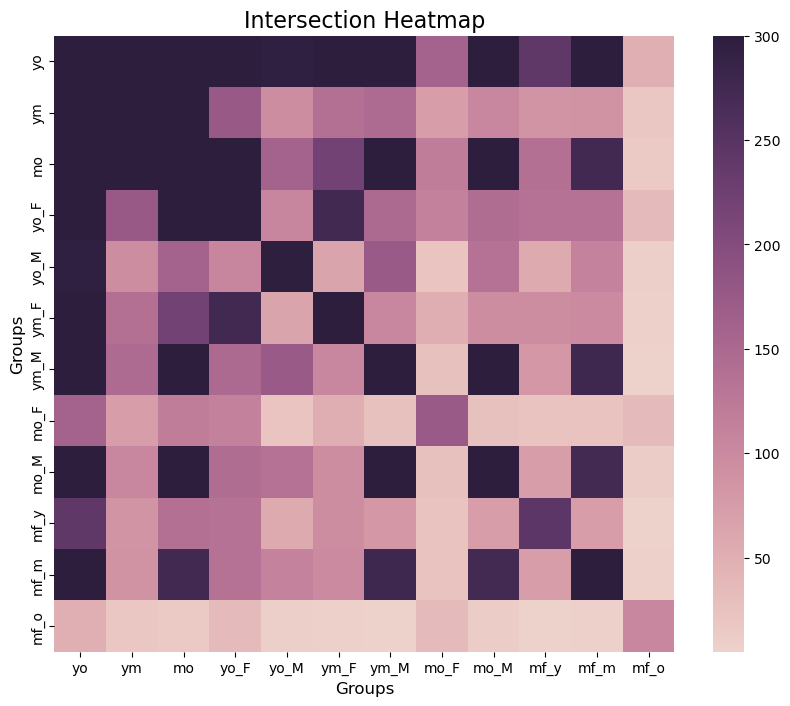

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming X is a DataFrame with boolean values
columns = X.columns
intersection_matrix = pd.DataFrame(index=columns, columns=columns, dtype=int)

# Compute intersections for each pair of columns
for col1 in columns:
    for col2 in columns:
        intersection_matrix.loc[col1, col2] = int((X[col1] & X[col2]).sum())

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(intersection_matrix, annot=False, vmax=300, cmap=sns.cubehelix_palette(as_cmap=True), cbar=True)

# Customize heatmap
plt.title("Intersection Heatmap", fontsize=16)
plt.xlabel("Groups", fontsize=12)
plt.ylabel("Groups", fontsize=12)
plt.savefig("results/Intersection_size_heatmap.png")
plt.show()


In [86]:
from scipy.cluster.hierarchy import linkage, leaves_list
interesting_groups = ['yo','ym','mo','yo_F','yo_M', 'ym_F','ym_M', 'mo_M','mo_F', ]
subset_matrix = intersection_matrix.loc[interesting_groups, interesting_groups]

subset_matrix

,yo,ym,mo,yo_F,yo_M,ym_F,ym_M,mo_M,mo_F
yo,2176.0,647.0,1093.0,545.0,296.0,382.0,490.0,485.0,160.0
ym,647.0,647.0,324.0,176.0,97.0,138.0,147.0,104.0,74.0
mo,1093.0,324.0,1093.0,336.0,160.0,221.0,306.0,312.0,118.0
yo_F,545.0,176.0,336.0,593.0,106.0,275.0,149.0,144.0,112.0
yo_M,296.0,97.0,160.0,106.0,298.0,66.0,174.0,135.0,22.0
ym_F,382.0,138.0,221.0,275.0,66.0,383.0,105.0,97.0,52.0
ym_M,490.0,147.0,306.0,149.0,174.0,105.0,492.0,331.0,27.0
mo_M,485.0,104.0,312.0,144.0,135.0,97.0,331.0,495.0,28.0
mo_F,160.0,74.0,118.0,112.0,22.0,52.0,27.0,28.0,175.0


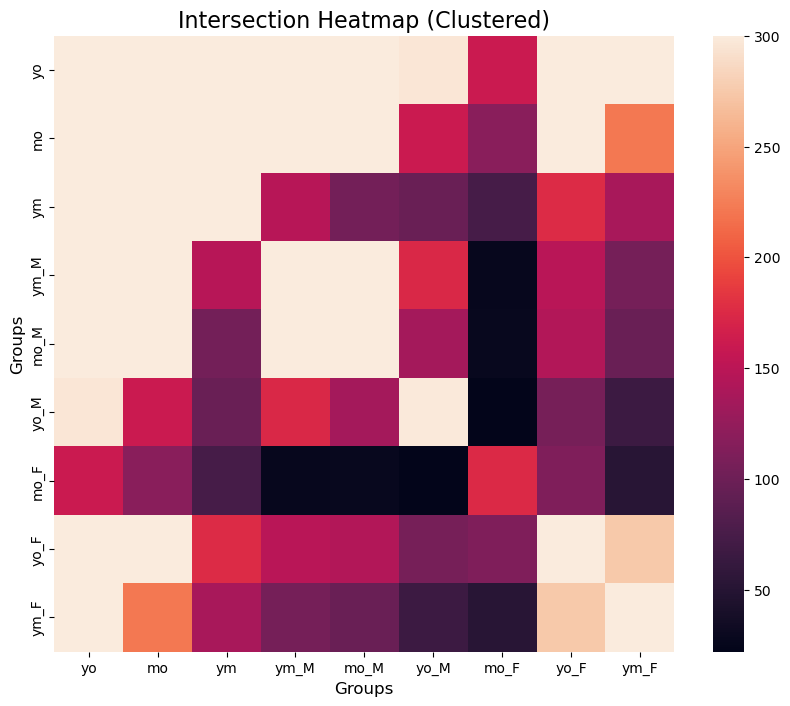

In [88]:
linkage_result = linkage(subset_matrix, method='average')
ordered_indices = leaves_list(linkage_result)

# Reorder rows and columns based on clustering
ordered_matrix = subset_matrix.iloc[ordered_indices, ordered_indices]


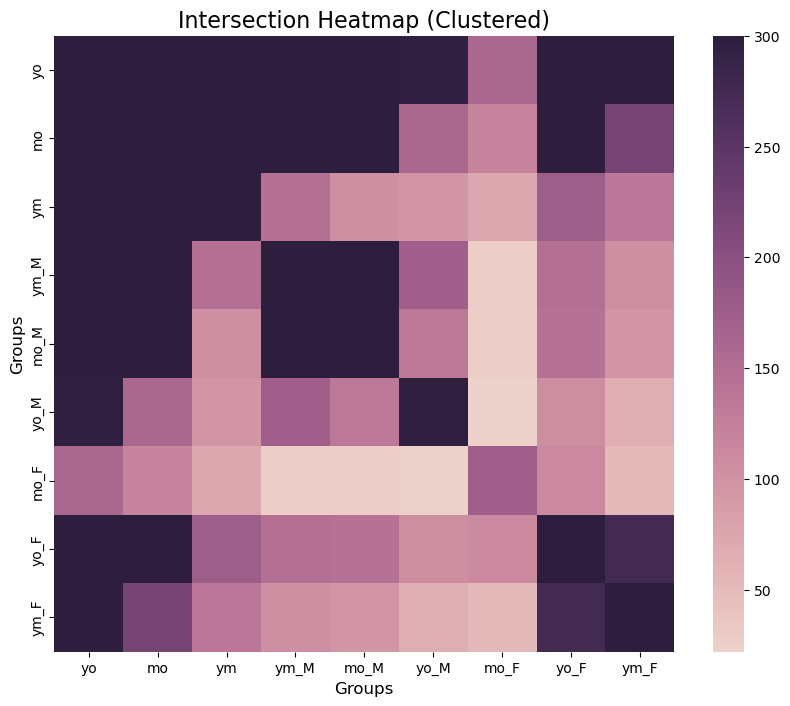

In [90]:

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(ordered_matrix, annot=False, vmax=300, cmap=sns.cubehelix_palette(as_cmap=True), cbar=True)
plt.title("Intersection Heatmap (Clustered)", fontsize=16)
plt.xlabel("Groups", fontsize=12)
plt.ylabel("Groups", fontsize=12)
plt.savefig("results/Intersection_size_heatmap_sorted_by_silimarity.png")

plt.show()

# Upset plot

In [111]:
interesting_groups = ['yo','ym','mo','yo_F','yo_M', 'ym_F','ym_M', 'mo_M','mo_F', ]
subset_df = X[interesting_groups]
# Assuming X is a dataframe where the index is the gene and columns represent sets
result_subset = {}

# Iterate over columns to extract genes marked as True
for col in subset_df.columns:
    # Filter genes where the column value is True
    genes = subset_df.index[subset_df[col] == True].tolist()
    # Add the list to the dictionary with the column name as the key
    result_subset[col] = genes

# Resulting dictionary


In [112]:
result_subset.keys()

dict_keys(['yo', 'ym', 'mo', 'yo_F', 'yo_M', 'ym_F', 'ym_M', 'mo_M', 'mo_F'])

/opt/conda/lib/python3.11/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/opt/conda/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/opt/conda/lib/

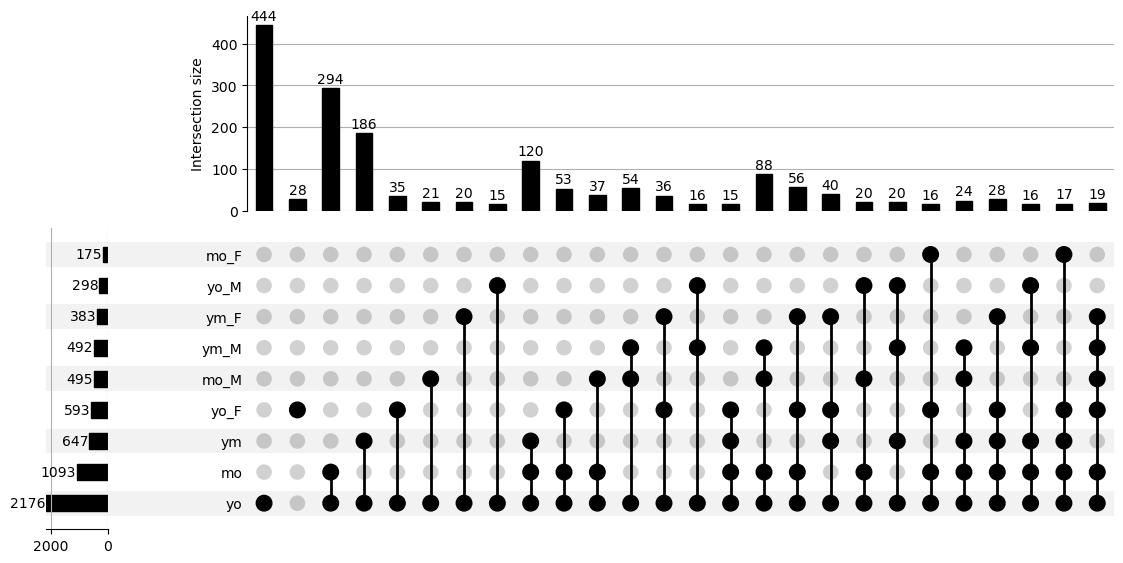

In [114]:
upset_data = from_contents(result_subset)
plot(upset_data, min_subset_size=15, show_counts=True)
pyplot.savefig("results/upset_plot_all_minusMvsF.png") 

In [ ]:
# Assuming result_subset is a dictionary where keys are set names and values are sets of elements
# For example: result_subset = {'yo': set(...), 'ym': set(...), 'mo': set(...)}

# Create a new dictionary to store the intersections
intersections_dict = {}

# Get all set names (keys)
set_names = list(result_subset.keys())

# Iterate over all pairs of set names
for i, set_name1 in enumerate(set_names):
    for set_name2 in set_names[i+1:]:  # To avoid repeating pairs, only look at sets after the first
        # Calculate the intersection
        intersection = set(result_subset[set_name1]).intersection(set(result_subset[set_name2]))
        
        # Add the intersection to the dictionary with a combination of the set names as the key
        key = f"{set_name1}_{set_name2}"
        intersections_dict[key] = list(intersection)




In [ ]:
import itertools

# Assuming result_subset is a dictionary where keys are set names and values are sets of elements
# For example: result_subset = {'yo': set(...), 'ym': set(...), 'mo': set(...)}

# Create a new dictionary to store the intersections
intersections_dict = {}

# Get all set names (keys)
set_names = list(result_subset.keys())

# Iterate over combinations of all sizes (2 to 6 sets)
for r in range(2, 7):  # r=2 for pairs, r=3 for triplets, etc.
    for combination in itertools.combinations(set_names, r):
        # Calculate the intersection of the sets in the combination
        intersection = set(result_subset[combination[0]])
        for set_name in combination[1:]:
            intersection &= set(result_subset[set_name])  # Update intersection with each additional set
        
        # Add to the dictionary only if the intersection has more than 15 elements
        if len(intersection) > 15:
            key = "_".join(combination)
            intersections_dict[key] = list(intersection)

# Sort the dictionary by the length of the intersection values in descending order
sorted_intersections_dict = dict(sorted(intersections_dict.items(), key=lambda item: len(item[1]), reverse=True))




In [ ]:
intersections_dict.keys()

In [140]:
import json 
   
# Convert and write JSON object to file
with open("results/Comon_genes.json", "w") as outfile: 
    json.dump(intersections_dict, outfile)


In [94]:
result.keys()
interesting_groups = ['yo','yo_M', 'yo_F']
interesting_groups_dict = {key: result[key] for key in interesting_groups if key in result}


In [95]:
upset_subset_data = from_contents(interesting_groups_dict)

/opt/conda/lib/python3.11/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


/opt/conda/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/opt/conda/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

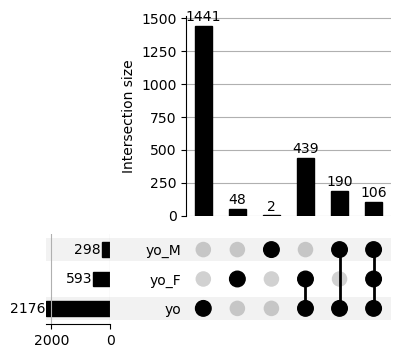

In [96]:
plot(upset_subset_data, min_subset_size=1, show_counts=True)

/opt/conda/lib/python3.11/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/opt/conda/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/opt/conda/lib/

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

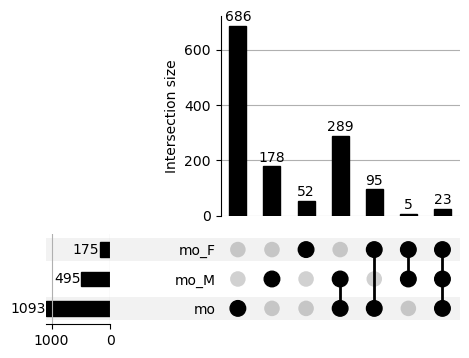

In [97]:
result.keys()
interesting_groups = ['mo','mo_M', 'mo_F']
interesting_groups_dict = {key: result[key] for key in interesting_groups if key in result}
upset_subset_data = from_contents(interesting_groups_dict)
plot(upset_subset_data, min_subset_size=1, show_counts=True)

In [35]:
all_de_df.head(10)

,yo,ym,mo,yo_F,yo_M,ym_F,ym_M,mo_F,mo_M,mf_y,mf_m,mf_o
CFH,-0.266518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.410560,NaN,-0.501766,NaN
SEMA3F,-4.102241,NaN,-3.743393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CFTR,-3.346279,NaN,-4.146497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RAD52,-0.556749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MYH16,7.573264,NaN,5.626051,-9.104072,6.659847,NaN,12.823101,NaN,-6.163253,4.321851,NaN,NaN
TFPI,-0.404481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.695375,NaN
RBM5,-0.151119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SLC7A2,-0.240796,-0.223356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.440208,NaN,NaN
ARF5,-4.739374,-3.607212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AK2,0.169081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.282416,0.372141,NaN


1

In [43]:
all_de_df.loc['ALDOA']

yo      0.512077
ym           NaN
mo           NaN
yo_F    1.300626
yo_M         NaN
ym_F         NaN
ym_M         NaN
mo_F         NaN
mo_M         NaN
mf_y    0.524438
mf_m    0.758441
mf_o    1.049616
Name: ALDOA, dtype: float64

In [37]:
all_de_df.isnull()

,yo,ym,mo,yo_F,yo_M,ym_F,ym_M,mo_F,mo_M,mf_y,mf_m,mf_o
CFH,False,True,True,True,True,True,True,True,False,True,False,True
SEMA3F,False,True,False,True,True,True,True,True,True,True,True,True
CFTR,False,True,False,True,True,True,True,True,True,True,True,True
RAD52,False,True,True,True,True,True,True,True,True,True,True,True
MYH16,False,True,False,False,False,True,False,True,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
Unnamed: 34254,False,True,True,True,True,True,True,True,True,True,True,True
Unnamed: 34260,False,True,True,True,True,True,True,True,True,True,True,True
Unnamed: 34273,False,True,False,True,True,True,True,True,True,True,True,True
PDE4C.1,False,False,False,True,False,True,False,True,False,True,False,True


In [38]:
all_de_df.head()

,yo,ym,mo,yo_F,yo_M,ym_F,ym_M,mo_F,mo_M,mf_y,mf_m,mf_o
CFH,-0.266518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.410560,NaN,-0.501766,NaN
SEMA3F,-4.102241,NaN,-3.743393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CFTR,-3.346279,NaN,-4.146497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RAD52,-0.556749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MYH16,7.573264,NaN,5.626051,-9.104072,6.659847,NaN,12.823101,NaN,-6.163253,4.321851,NaN,NaN


In [44]:
all_de_df.to_csv("results/RNAseq_abundance_adjusted_combat_inmose_all_lfc.csv")

In [45]:
all_de_df.dropna(how='any')


,yo,ym,mo,yo_F,yo_M,ym_F,ym_M,mo_F,mo_M,mf_y,mf_m,mf_o


In [46]:
for index, row in all_de_df[:3].iterrows():
    print(dict(row))
    print(index)

{'yo': -0.2665178557265618, 'ym': nan, 'mo': nan, 'yo_F': nan, 'yo_M': nan, 'ym_F': nan, 'ym_M': nan, 'mo_F': nan, 'mo_M': -0.4105602126569657, 'mf_y': nan, 'mf_m': -0.5017662860645844, 'mf_o': nan}
CFH
{'yo': -4.102240623690333, 'ym': nan, 'mo': -3.743392825322583, 'yo_F': nan, 'yo_M': nan, 'ym_F': nan, 'ym_M': nan, 'mo_F': nan, 'mo_M': nan, 'mf_y': nan, 'mf_m': nan, 'mf_o': nan}
SEMA3F
{'yo': -3.346279167877878, 'ym': nan, 'mo': -4.1464965299896495, 'yo_F': nan, 'yo_M': nan, 'ym_F': nan, 'ym_M': nan, 'mo_F': nan, 'mo_M': nan, 'mf_y': nan, 'mf_m': nan, 'mf_o': nan}
CFTR


In [78]:
ddf_dict = [{'index': 'CFH','yo': -0.2665178557265618, 'ym': 3, 'mo': None, 'ml_c': None, 'ml_s': -0.5},
                {'index': 'SEMA3F','yo': -4.10, 'ym': None, 'mo': -3, 'ml_c': None, 'ml_s': None},
                {'index': 'CFTR', 'yo': -3.34, 'ym': None, 'mo': -4, 'ml_c': None, 'ml_s': 0.5}]
df = pd.DataFrame.from_dict(ddf_dict)
df

,index,yo,ym,mo,ml_c,ml_s
0,CFH,-0.266518,3.0,NaN,None,-0.5
1,SEMA3F,-4.100000,NaN,-3.0,None,NaN
2,CFTR,-3.340000,NaN,-4.0,None,0.5


In [47]:
df = df.set_index('index')
df

KeyError: "None of ['index'] are in the columns"